In [3]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="ticks", context="notebook")

In [4]:
# Discover and load prediction CSVs
from pathlib import Path

def find_results_dir(start: Path = Path.cwd()) -> Path:
    # Walk up until we find the repo folder that contains Prediction_Results
    for p in [start] + list(start.parents):
        cand = p / 'Prediction_Results'
        if cand.exists() and cand.is_dir():
            return cand
    raise FileNotFoundError("Could not locate 'Prediction_Results' directory by walking up from current path.")

results_dir = find_results_dir()

csv_files = sorted(results_dir.glob('*_kiba.csv'))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir}")

csv_files

[PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/GBM_predictions_kiba.csv'),
 PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/Linear_Regression_predictions_kiba.csv'),
 PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/MLP_predictions_kiba.csv'),
 PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/Random_Forest_predictions_kiba.csv'),
 PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/SVR_predictions_kiba.csv'),
 PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Prediction_Results/XGBoost_predictions_kiba.csv')]

In [5]:
# Load and standardize columns: Affinity (true), Predicted (prediction), and Split
from typing import Tuple, List

ID_COLS = ['Index_ID','Drug_ID','Target_ID']


def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    # Clean up column names: strip whitespace and unify multiple spaces
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    cols = {c.lower(): c for c in df.columns}
    # Prefer explicit columns (case-insensitive)
    true_col = cols.get('affinity')
    pred_col = cols.get('predicted')
    split_col = cols.get('split')
    # Fallbacks if needed
    if true_col is None:
        for c in ['true', 'y_true', 'label', 'affinity_true']:
            if c in cols:
                true_col = cols[c]
                break
    if pred_col is None:
        for c in ['y_pred', 'pred', 'prediction', 'affinity_pred']:
            if c in cols:
                pred_col = cols[c]
                break
    if split_col is None:
        for c in ['set', 'fold', 'partition']:
            if c in cols:
                split_col = cols[c]
                break
    if true_col is None or pred_col is None:
        raise ValueError(f"Expected columns 'Affinity' (true) and 'Predicted' (prediction) not found. Got: {list(df.columns)}")
    out = df.rename(columns={true_col: 'y_true', pred_col: 'y_pred'})
    if split_col and split_col in out.columns:
        out = out.rename(columns={split_col: 'Split'})
    else:
        # No Unknown category requested; use NaN when Split is missing
        out['Split'] = np.nan
    # Keep optional metadata columns if present
    keep_extra = [c for c in ID_COLS if c in out.columns]
    return out[['y_true', 'y_pred', 'Split'] + keep_extra]

# Load all files into a tidy dataframe with model name inferred from filename
frames = []
for f in csv_files:
    df = pd.read_csv(f)
    std = standardize_df(df)
    std['model'] = f.stem.replace('_predictions', '')
    frames.append(std)

all_preds = pd.concat(frames, ignore_index=True)
# Filter to allowed splits only (no Unknown)
allowed_splits = ['Train', 'Validation', 'Test']
all_preds = all_preds[all_preds['Split'].isin(allowed_splits)].copy()
# Ensure Split is categorical with a preferred order
all_preds['Split'] = pd.Categorical(all_preds['Split'], categories=allowed_splits, ordered=True)
all_preds.head()

,y_true,y_pred,Split,Index_ID,Drug_ID,Target_ID,model
0,7.953876,7.937121,Train,Kiba921,CHEMBL210928,Q13464,GBM_kiba
1,7.954677,7.945564,Train,Kiba19082,CHEMBL1979554,Q16644,GBM_kiba
2,7.847706,7.915314,Train,Kiba112064,CHEMBL1986855,P24941,GBM_kiba
3,7.924453,7.920112,Train,Kiba115038,CHEMBL1985095,Q08881,GBM_kiba
4,7.924453,7.922503,Train,Kiba47231,CHEMBL482967,Q96PF2,GBM_kiba


In [6]:
all_preds['y_true'].describe()

count    705942.000000
mean          7.932195
std           0.042313
min           7.764467
25%           7.923581
50%           7.938539
75%           7.950782
max          18.000000
Name: y_true, dtype: float64

In [7]:
# Compute metrics per model AND per split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr


def compute_metrics(df: pd.DataFrame) -> dict:
    y_true = df['y_true'].astype(float)
    y_pred = df['y_pred'].astype(float)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    if y_true.nunique() > 1 and y_pred.nunique() > 1:
        pearson = pearsonr(y_true, y_pred)[0]
        spearman = spearmanr(y_true, y_pred)[0]
    else:
        pearson = np.nan
        spearman = np.nan
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Pearson': pearson,
        'Spearman': spearman,
    }

metrics_rows = []
for (name, split), g in all_preds.groupby(['model','Split']):
    row = {'model': name, 'Split': split}
    row.update(compute_metrics(g))
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values(by=['Split','MAE','RMSE'])
metrics_df.reset_index(drop=True, inplace=True)
metrics_df

/var/folders/_0/j8xw5t8j6p3dg7_fq82t36gr0000gp/T/ipykernel_1407/163650798.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (name, split), g in all_preds.groupby(['model','Split']):


,model,Split,MAE,MSE,RMSE,R2,Pearson,Spearman
0,XGBoost_kiba,Test,0.013004,0.000992,0.031502,0.015165,0.658057,0.760098
1,GBM_kiba,Test,0.017229,0.001107,0.033267,-0.098260,0.398063,0.614153
2,Random_Forest_kiba,Test,0.021289,0.001085,0.032933,-0.076323,0.063836,0.102564
3,Linear_Regression_kiba,Test,0.023971,0.001019,0.031915,-0.010804,0.444368,0.405531
4,SVR_kiba,Test,0.040452,0.002166,0.046539,-1.149474,0.121737,0.079286
5,MLP_kiba,Test,6.077945,36.976534,6.080833,-36694.816347,0.110500,0.107320
6,XGBoost_kiba,Train,0.010665,0.000236,0.015357,0.890705,0.944707,0.832730
7,GBM_kiba,Train,0.016735,0.000687,0.026201,0.681867,0.849660,0.623296
8,Random_Forest_kiba,Train,0.021221,0.002234,0.047270,-0.035459,0.036790,0.082544
9,Linear_Regression_kiba,Train,0.023857,0.002166,0.046541,-0.003750,0.314478,0.410785


In [8]:
metrics_df.to_csv('./model_evaluation_metrics_by_split_Kiba.csv', index=False)

PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Evaluation_Metrics/figures/pred_vs_true_scatter_by_model_hue_split_Kiba.png')

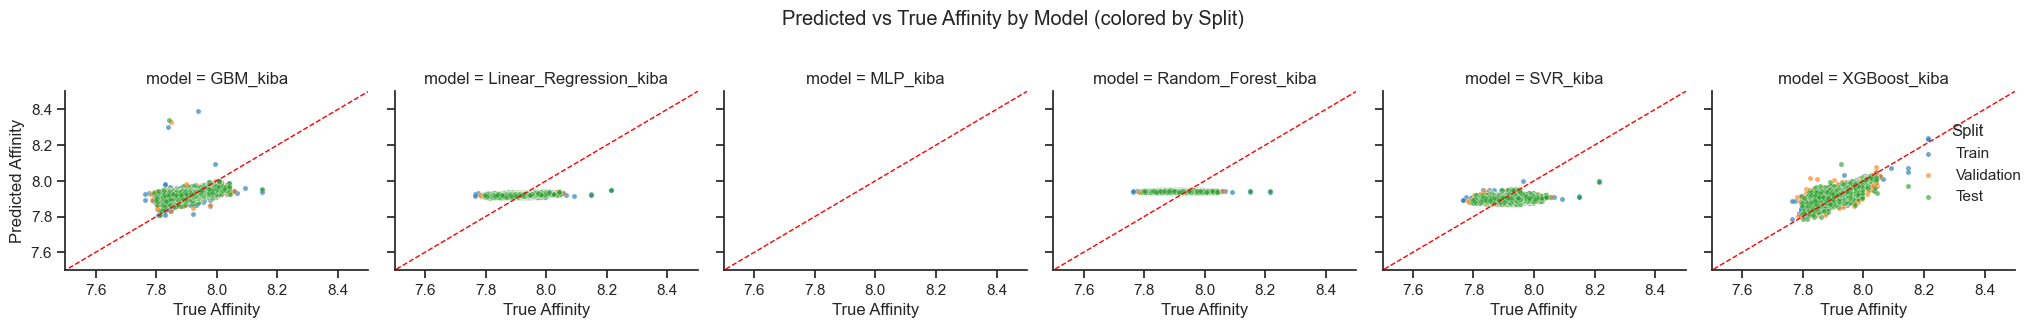

In [9]:
# Scatter plots: Predicted vs True per model, colored by Split (one subplot per model)
fig_dir = results_dir.parent / 'Evaluation_Metrics' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# Determine splits present and build a safe palette
splits_present = [s for s in pd.Series(all_preds['Split']).astype(str).dropna().unique().tolist()]
palette_base = {
    'Train': '#1f77b4',
    'Validation': '#ff7f0e',
    'Test': '#2ca02c',
    'Unknown': '#7f7f7f',
}
palette = {k: palette_base.get(k, '#7f7f7f') for k in splits_present}

# Facet by Model; color by Split
g = sns.FacetGrid(all_preds, col="model", sharex=True, sharey=True, height=3.2, margin_titles=True, hue="Split", palette=palette)
g.map_dataframe(sns.scatterplot, x='y_true', y='y_pred', s=14, alpha=0.65)

# Add y=x line to each facet
min_v = np.nanmin(all_preds[['y_true','y_pred']].values)
max_v = np.nanmax(all_preds[['y_true','y_pred']].values)
for ax in g.axes.flatten():
    ax.plot([min_v, max_v], [min_v, max_v], ls='--', c='red', lw=1)
    ax.set_xlabel('True Affinity')
    ax.set_ylabel('Predicted Affinity')
    ax.set_xlim(7.5, 8.5)
    ax.set_ylim(7.5, 8.5)

# Add legend once
g.add_legend(title='Split')

g.fig.suptitle('Predicted vs True Affinity by Model (colored by Split)', y=1.02)
plt.tight_layout()
scatter_path = fig_dir / 'pred_vs_true_scatter_by_model_hue_split_Kiba.png'
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
scatter_path

/var/folders/_0/j8xw5t8j6p3dg7_fq82t36gr0000gp/T/ipykernel_1407/1505952469.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, rotation=0, ha='center', fontsize=10)


PosixPath('/Users/cheng.wang/Documents/GitHub/llm-drug-agent/Evaluation_Metrics/figures/residuals_boxplot_by_split_Kiba.png')

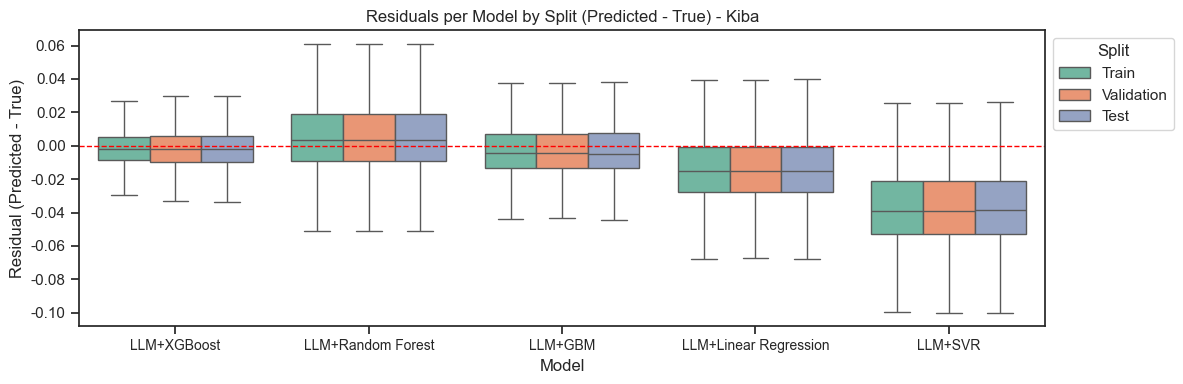

In [24]:
# Residual box plot per model and split
all_preds['residual'] = all_preds['y_pred'] - all_preds['y_true']
all_preds['Model'] = all_preds['model'].str.replace('_kiba', '')
# Filter out MLP model
all_preds_filtered = all_preds[all_preds['Model'] != 'MLP'].copy()

# Calculate median absolute residual for each model to determine ordering
model_residual_perf = all_preds_filtered.groupby('Model')['residual'].apply(lambda x: np.abs(x.median())).sort_values()
model_order = model_residual_perf.index.tolist()

plt.figure(figsize=(12, 4))
# Use Nature Journal style colorblind-friendly palette and hide outliers
# Order models by residual performance (best to worst)
ax = sns.boxplot(data=all_preds_filtered, x='Model', y='residual', hue='Split', palette='Set2', showfliers=False, order=model_order)
plt.axhline(0, ls='--', c='red', lw=1)

# Customize x-axis labels
model_label_map = {
    'Linear_Regression': 'LLM+Linear Regression',
    'Random_Forest': 'LLM+Random Forest',
    'SVR': 'LLM+SVR',
    'MLP': 'LLM+MLP',
    'GBM': 'LLM+GBM',
    'XGBoost': 'LLM+XGBoost'
}
# Get current labels and map them
current_labels = [t.get_text() for t in ax.get_xticklabels()]
custom_labels = [model_label_map.get(label, label.replace('_', ' ')) for label in current_labels]
ax.set_xticklabels(custom_labels, rotation=0, ha='center', fontsize=10)

plt.title('Residuals per Model by Split (Predicted - True) - Kiba')
plt.ylabel('Residual (Predicted - True)')
# Format y-axis to show 2 decimal places
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.2f}'))
plt.legend(title='Split', bbox_to_anchor=(1.0, 1), loc='upper left')
box_path = fig_dir / 'residuals_boxplot_by_split_Kiba.png'
plt.tight_layout()
# Use fixed bbox to ensure consistent output size across all notebooks
plt.savefig(box_path, dpi=300, bbox_inches='tight', pad_inches=0.2)
box_path

## Metrics summary
The table below summarizes error and correlation metrics per model. Lower MAE/RMSE and higher R2/Correlations are better.

In [11]:
# Show metrics
metrics_df

,model,Split,MAE,MSE,RMSE,R2,Pearson,Spearman
0,XGBoost_kiba,Test,0.013004,0.000992,0.031502,0.015165,0.658057,0.760098
1,GBM_kiba,Test,0.017229,0.001107,0.033267,-0.098260,0.398063,0.614153
2,Random_Forest_kiba,Test,0.021289,0.001085,0.032933,-0.076323,0.063836,0.102564
3,Linear_Regression_kiba,Test,0.023971,0.001019,0.031915,-0.010804,0.444368,0.405531
4,SVR_kiba,Test,0.040452,0.002166,0.046539,-1.149474,0.121737,0.079286
5,MLP_kiba,Test,6.077945,36.976534,6.080833,-36694.816347,0.110500,0.107320
6,XGBoost_kiba,Train,0.010665,0.000236,0.015357,0.890705,0.944707,0.832730
7,GBM_kiba,Train,0.016735,0.000687,0.026201,0.681867,0.849660,0.623296
8,Random_Forest_kiba,Train,0.021221,0.002234,0.047270,-0.035459,0.036790,0.082544
9,Linear_Regression_kiba,Train,0.023857,0.002166,0.046541,-0.003750,0.314478,0.410785
